# Box Office Prediction Model

Predict a film's **worldwide gross** from information known before release: budget, star power, MPAA rating, genres, release timing, studio and release scale.

**Input:** `reference_docs/box_office_refined_starpower.csv`, built by `dataset_refiner.ipynb` and then `starpower.py` (see `WORKFLOW.md`)

**Approach**
1. Load and clean the data
2. Quick EDA to sanity-check the data
3. Feature engineering: one function per feature group, so each group can be tweaked or switched off on its own
4. Time-based train/test split (train on older films, test on the most recent ones)
5. Compare a median baseline, **multiple linear regression**, **Huber regression** (outlier-resistant linear) and **gradient boosting**
6. Inspect the results: coefficients, feature importance, biggest misses
7. Helper to predict a new, unreleased film

**Target:** `log(Worldwide)`. Grosses are heavily right-skewed, so a log scale stops a few blockbusters from dominating the fit. It also means coefficients read as *percentage* effects. Converting a prediction back with `exp()` gives a *typical* (median-like) gross, not a mean.

All tunable settings live in the **Config** cell. Each section only depends on the variables created in earlier sections, so you can re-run any cell after changing it.

## 1. Imports & config

In [175]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [176]:
# ---- Data ----
DATA_PATH = Path("reference_docs/box_office_refined_starpower.csv")

# ---- Cleaning ----
MIN_WORLDWIDE = 100_000                   # films below this are streaming / token releases, not real theatrical runs
AS_OF_DATE = pd.Timestamp("2026-10-03")   # when the grosses were collected
RECENT_RELEASE_WEEKS = 8                  # films younger than this are still earning, so their gross is incomplete
# Toggles for the films dataset_refiner flags. True = leave them out of training AND testing.
EXCLUDE_NETFLIX = True                    # token theatrical runs before streaming
EXCLUDE_ANIME = True                      # huge worldwide grosses on tiny budgets; not the films we want to predict
EXCLUDE_CHINESE = True                    # grosses mostly from the Chinese home market

# ---- Features ----
RARE_GENRE_MIN_COUNT = 15                 # genres with fewer training films are folded into genre_Other
ALWAYS_KEEP_GENRES = ["Anime"]            # kept as their own column even when rarer than the threshold
STARPOWER_ENCODING = "dummies"            # "dummies" (A/B vs C) or "ordinal" (C=0, B=1, A=2)
STARPOWER_LEVELS = ["C", "B", "A"]        # first level is the baseline that dummies are compared against
RATING_MERGE = {"G": "PG"}                # fold tiny rating categories into a neighbour (only 4 G films)
RATING_LEVELS = ["PG", "PG-13", "R", "NR"]  # first level is the baseline
COVID_ERA_END = pd.Timestamp("2022-01-01")  # releases before this get covid_era = 1

MONTH_TO_SEASON = {
    1: "winter", 2: "winter",
    3: "spring", 4: "spring",
    5: "summer", 6: "summer", 7: "summer", 8: "summer",
    9: "fall", 10: "fall",
    11: "holiday", 12: "holiday",
}
SEASON_LEVELS = ["fall", "winter", "spring", "summer", "holiday"]  # first level is the baseline

# Exact company names as they appear in "Production Companies"
MAJOR_STUDIOS = {
    "Universal Pictures", "Illumination", "DreamWorks Animation", "DreamWorks Pictures",
    "Columbia Pictures", "Sony Pictures", "Sony Pictures Animation", "Screen Gems",
    "Warner Bros. Pictures", "Warner Animation Group", "Warner Bros. Animation", "New Line Cinema",
    "Legendary Pictures",
    "Paramount Pictures", "Paramount Animation", "Paramount Players",
    "Walt Disney Pictures", "Walt Disney Animation Studios", "Pixar", "Marvel Studios",
    "Lucasfilm Ltd.", "20th Century Studios",
    "Lionsgate", "Metro-Goldwyn-Mayer", "Amazon MGM Studios",
}

# ---- Modelling ----
TEST_FRACTION = 0.2      # most recent 20% of films are held out as the test set
CV_SPLITS = 5            # folds for time-series cross-validation on the training set
RANDOM_STATE = 42

# Huber: residuals beyond HUBER_EPSILON x (estimated residual scale) get linear rather than squared
# weight, so breakout hits and flops can't drag the fit around. Lower = more films capped.
# The textbook 1.35 capped ~37% of training films here (box office residuals are wide); 2.5 caps only the
# most extreme ~2.5%. See the epsilon sweep in section 11.
HUBER_EPSILON = 2.5
HUBER_MAX_ITER = 2000

GBM_PARAMS = dict(
    max_iter=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=RANDOM_STATE,
)

# ---- Prediction report (section 14) ----
PRIMARY_MODEL = "Huber regression"      # model behind the report's headline numbers
BREAKEVEN_MULTIPLE = 2.5                # worldwide gross needed, as a multiple of production budget, to break even
PROBABILITY_MULTIPLES = [1.0, 2.0, 2.5, 3.0, 5.0]   # rows of the "chance of reaching" table
BUDGET_RANGE_POINTS = 5                 # budgets evaluated across a (low, high) range; odd so the midpoint is included
MIN_SEGMENT_FILMS = 30                  # segments with fewer out-of-sample films fall back to the overall spread

## 2. Load data

In [177]:
def load_data(path: Path) -> pd.DataFrame:
    """Read the CSV, parse release dates and sort oldest to newest (the time split relies on this order)."""
    df = pd.read_csv(path)
    df["Release Date"] = pd.to_datetime(df["Release Date"])
    df = df.sort_values("Release Date").reset_index(drop=True)
    return df

In [178]:
raw = load_data(DATA_PATH)
print(f"{len(raw)} films, {raw['Release Date'].min():%Y-%m-%d} to {raw['Release Date'].max():%Y-%m-%d}")
print("\nMissing values per column:")
print(raw.isna().sum())
raw.head()

931 films, 2021-01-15 to 2026-09-25

Missing values per column:
Movie                     0
Release Date              0
Production Companies      0
Opening                 931
Budget                    0
Rating                    0
Genres                    0
Domestic                931
International           931
Worldwide                 0
TMDB ID                   0
Is Netflix                0
Is Anime                  0
Is Chinese                0
Original Language         0
US Wide Release           0
Flag Source             894
Starpower Rating          0
dtype: int64


,Movie,Release Date,Production Companies,Opening,Budget,Rating,Genres,Domestic,International,Worldwide,TMDB ID,Is Netflix,Is Anime,Is Chinese,Original Language,US Wide Release,Flag Source,Starpower Rating
0,The Marksman,2021-01-15,"Sculptor Media, Zero Gravity Management, Cutti...",NaN,23000000.0,PG-13,"Action, Drama, Thriller",NaN,NaN,23076711.0,634528,0,0,0,en,1,NaN,A
1,Nomadland,2021-01-29,"Cor Cordium Productions, Hear/Say Productions,...",NaN,5000000.0,R,Drama,NaN,NaN,39458207.0,581734,0,0,0,en,1,NaN,B
2,The Little Things,2021-01-29,"Warner Bros. Pictures, Gran Via Productions",NaN,30000000.0,R,"Drama, Crime, Thriller",NaN,NaN,29942746.0,602269,0,0,0,en,1,NaN,A
3,Music,2021-02-10,"Atlantic Films, Pineapple Lasagne Productions,...",NaN,16000000.0,PG-13,"Music, Drama",NaN,NaN,645949.0,586101,0,0,0,en,1,NaN,C
4,Judas and the Black Messiah,2021-02-12,"MACRO, Bron Studios, Participant, Proximity Media",NaN,26000000.0,R,"Drama, History",NaN,NaN,6416063.0,583406,0,0,0,en,1,NaN,B


## 3. Clean

Four steps, each its own function so you can change or skip it:
- **Drop fully empty columns.** `Opening`, `Domestic` and `International` have no values. (Opening weekend would be leakage anyway if we're predicting before release.)
- **Drop flagged film groups**, each with its own toggle in Config. `dataset_refiner.ipynb` sets the flags:
  - `EXCLUDE_NETFLIX`: the "worldwide gross" is a token limited run before streaming, e.g. *Frankenstein* at $0.5M.
  - `EXCLUDE_ANIME`: *Demon Slayer*, *Chainsaw Man* and similar earn 20–47x their budget worldwide, mostly outside the US.
  - `EXCLUDE_CHINESE`: *Ne Zha 2* and similar earn mostly in China.

  These are removed from **both** training and testing, since they're out of scope for the predictions we want. Set a toggle to `False` to bring that group back in. Its feature (`genre_Anime`, `is_chinese`, `is_netflix`) then gets added automatically.
- **Drop tiny grosses.** Films under `MIN_WORLDWIDE` are mostly streaming releases or token theatrical runs. On a log scale they become huge outliers.
- **Drop recent releases.** Films released within `RECENT_RELEASE_WEEKS` of `AS_OF_DATE` are still in theatres, so their gross is understated.

In [179]:
def drop_empty_columns(df: pd.DataFrame) -> pd.DataFrame:
    empty = [c for c in df.columns if df[c].isna().all()]
    print(f"Dropping fully empty columns: {empty}")
    return df.drop(columns=empty)


def drop_flagged_films(df: pd.DataFrame, flag_column: str) -> pd.DataFrame:
    mask = df[flag_column] == 1
    print(f"Dropping {mask.sum()} films with {flag_column} = 1: {df.loc[mask, 'Movie'].tolist()[:6]}{' ...' if mask.sum() > 6 else ''}")
    return df.loc[~mask].reset_index(drop=True)


def drop_tiny_grosses(df: pd.DataFrame, min_worldwide: float) -> pd.DataFrame:
    mask = df["Worldwide"] < min_worldwide
    print(f"Dropping {mask.sum()} films grossing under ${min_worldwide:,.0f}")
    return df.loc[~mask].reset_index(drop=True)


def drop_recent_releases(df: pd.DataFrame, as_of: pd.Timestamp, weeks: int) -> pd.DataFrame:
    cutoff = as_of - pd.Timedelta(weeks=weeks)
    mask = df["Release Date"] > cutoff
    print(f"Dropping {mask.sum()} films released after {cutoff:%Y-%m-%d} (still in release)")
    return df.loc[~mask].reset_index(drop=True)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df = drop_empty_columns(df)
    for flag_column, exclude in [("Is Netflix", EXCLUDE_NETFLIX), ("Is Anime", EXCLUDE_ANIME), ("Is Chinese", EXCLUDE_CHINESE)]:
        if exclude:
            df = drop_flagged_films(df, flag_column)
    df = drop_tiny_grosses(df, MIN_WORLDWIDE)
    df = drop_recent_releases(df, AS_OF_DATE, RECENT_RELEASE_WEEKS)
    return df

Preview what the gross filter will catch (the flag columns show which ones a toggle above would already remove):

In [180]:
raw.loc[raw["Worldwide"] < MIN_WORLDWIDE, ["Movie", "Release Date", "Budget", "Worldwide", "Is Netflix", "Is Anime", "Is Chinese"]]

,Movie,Release Date,Budget,Worldwide,Is Netflix,Is Anime,Is Chinese
16,Roe v. Wade,2021-04-02,6750000.0,23561.0,0,0,0
20,Mainstream,2021-05-07,5000000.0,49638.0,0,0,0
45,Die in a Gunfight,2021-07-16,4000000.0,31395.0,0,0,0
75,Old Henry,2021-10-01,1500000.0,77463.0,0,0,0
105,Castle Falls,2021-12-03,4000000.0,2643.0,0,0,0
111,The Lady of Heaven,2021-12-10,15000000.0,74441.0,0,0,0
116,Fortress,2021-12-17,20000000.0,52169.0,0,0,0
166,Fortress: Sniper's Eye,2022-04-29,22000000.0,69075.0,0,0,0
208,One Way,2022-09-02,5000000.0,30272.0,0,0,0
223,The Inhabitant,2022-10-07,1600000.0,36972.0,0,0,0


In [181]:
films = clean_data(raw)
print(f"\n{len(films)} films remain ({len(raw) - len(films)} removed)")

Dropping fully empty columns: ['Opening', 'Domestic', 'International']
Dropping 19 films with Is Netflix = 1: ['Army of the Dead', 'Red Notice', 'The Summit of the Gods', 'The Hand of God', "Don't Look Up", 'The Lost Daughter'] ...
Dropping 9 films with Is Anime = 1: ['Demon Slayer -Kimetsu no Yaiba- The Movie: Mugen Train', 'Evangelion: 3.0+1.0 Thrice Upon a Time', 'Suzume', 'The Boy and the Heron', 'SPY x FAMILY CODE: White', 'HAIKYU!! The Dumpster Battle'] ...
Dropping 9 films with Is Chinese = 1: ['The Wandering Earth II', 'Deep Sea', 'Yolo', 'The Prosecutor', 'Creation of the Gods II: Demon Force', 'Ne Zha 2'] ...
Dropping 25 films grossing under $100,000
Dropping 24 films released after 2026-08-08 (still in release)

845 films remain (86 removed)


## 4. Quick EDA

Sanity checks to confirm that the log transform makes sense and the main signals are present.

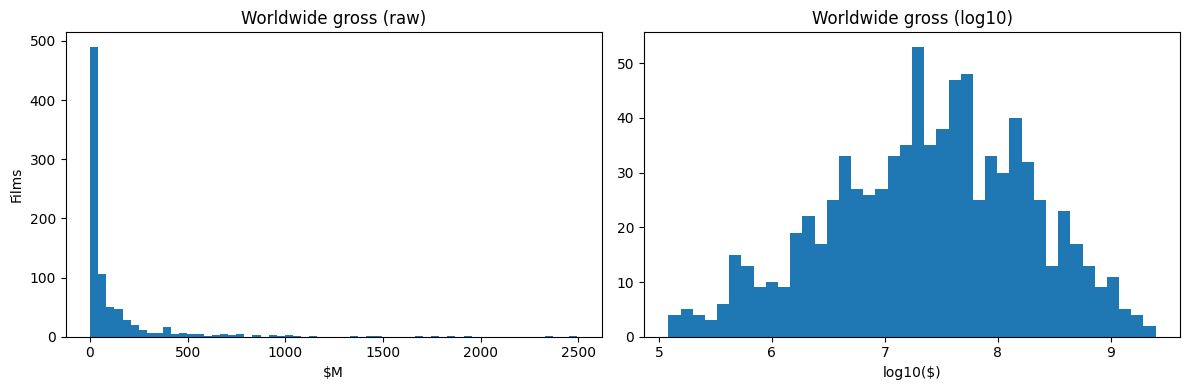

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(films["Worldwide"] / 1e6, bins=60)
axes[0].set(title="Worldwide gross (raw)", xlabel="$M", ylabel="Films")
axes[1].hist(np.log10(films["Worldwide"]), bins=40)
axes[1].set(title="Worldwide gross (log10)", xlabel="log10($)")
plt.tight_layout()
plt.show()

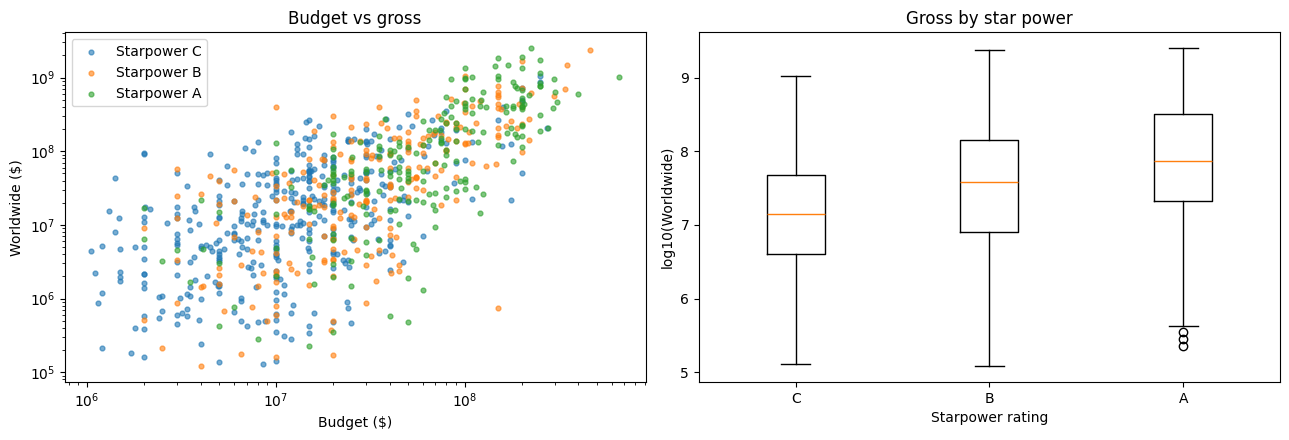

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for level in STARPOWER_LEVELS:
    subset = films[films["Starpower Rating"] == level]
    axes[0].scatter(subset["Budget"], subset["Worldwide"], s=12, alpha=0.6, label=f"Starpower {level}")
axes[0].set(xscale="log", yscale="log", xlabel="Budget ($)", ylabel="Worldwide ($)", title="Budget vs gross")
axes[0].legend()

log_ww_by_star = [np.log10(films.loc[films["Starpower Rating"] == lvl, "Worldwide"]) for lvl in STARPOWER_LEVELS]
axes[1].boxplot(log_ww_by_star, tick_labels=STARPOWER_LEVELS)
axes[1].set(xlabel="Starpower rating", ylabel="log10(Worldwide)", title="Gross by star power")

plt.tight_layout()
plt.show()

In [184]:
# Median gross and film count per genre (a film counts toward every genre it has)
genre_long = films.assign(Genre=films["Genres"].str.split(", ")).explode("Genre")
(
    genre_long.groupby("Genre")["Worldwide"]
    .agg(films="count", median_worldwide_m=lambda s: s.median() / 1e6)
    .sort_values("median_worldwide_m", ascending=False)
    .round(1)
)

,films,median_worldwide_m
Genre,,
Adventure,177,139.2
Science Fiction,123,130.8
Family,105,116.6
Animation,81,85.9
Fantasy,101,73.6
Action,230,64.7
Mystery,78,35.7
Horror,162,35.1
Crime,111,32.7


## 5. Train / test split (by release date)

The model will be used to predict *upcoming* films, so the test set is the most recent `TEST_FRACTION` of releases. A random split would let the model "see the future" (later films, market trends), which makes test scores look better than they really are.

The split happens **before** feature engineering. Anything learned from the data, like which genres count as "rare", comes from the training set only.

In [185]:
def time_split(df: pd.DataFrame, test_fraction: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split a date-sorted frame: oldest films -> train, newest -> test."""
    n_test = int(round(len(df) * test_fraction))
    train = df.iloc[:-n_test].reset_index(drop=True)
    test = df.iloc[-n_test:].reset_index(drop=True)
    for name, part in [("train", train), ("test", test)]:
        print(f"{name:>5}: {len(part):4d} films, "
              f"{part['Release Date'].min():%Y-%m-%d} to {part['Release Date'].max():%Y-%m-%d}")
    return train, test

In [186]:
train_films, test_films = time_split(films, TEST_FRACTION)

train:  676 films, 2021-01-15 to 2025-09-04
 test:  169 films, 2025-09-05 to 2026-08-07


## 6. Feature engineering

Each `make_*_features` function takes the cleaned films frame and returns a **new** DataFrame of feature columns with the same index. `build_features` concatenates them, so you can drop a feature group by commenting out one line.

Encoding choices:
| Group | Encoding | Notes |
|---|---|---|
| Budget | `log_budget` | Log-log with the target, so its coefficient is an *elasticity* |
| Star power | dummies vs baseline **C** (or ordinal) | Controlled by `STARPOWER_ENCODING` |
| Rating | dummies vs baseline **PG** | G merged into PG |
| Genres | **multi-hot**: one 0/1 column per genre | Films have several genres, so these aren't mutually exclusive and **no** baseline column is dropped. Rare genres go to `genre_Other`, except those in `ALWAYS_KEEP_GENRES` (`Anime`, added by the refiner) |
| Release timing | season dummies vs baseline **fall** + `covid_era` flag | |
| Studio | `major_studio` flag | 880 unique company strings is too many to dummy directly |
| Distribution | `us_wide_release` (+ `is_netflix` / `is_chinese` when those films are kept) | From the refiner: TMDB has a wide (not just limited) US theatrical release |

The categorical encoders use fixed category lists, so a single new film always produces the same columns as training.

In [187]:
def make_budget_features(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({"log_budget": np.log(df["Budget"])}, index=df.index)

In [188]:
def make_starpower_features(df: pd.DataFrame, encoding: str) -> pd.DataFrame:
    if encoding == "ordinal":
        ordinal = {level: i for i, level in enumerate(STARPOWER_LEVELS)}
        return pd.DataFrame({"starpower": df["Starpower Rating"].map(ordinal)}, index=df.index)

    if encoding == "dummies":
        starpower = pd.Series(pd.Categorical(df["Starpower Rating"], categories=STARPOWER_LEVELS), index=df.index)
        return pd.get_dummies(starpower, prefix="starpower", drop_first=True, dtype=int)

    raise ValueError(f"Unknown STARPOWER_ENCODING: {encoding!r}")

In [189]:
def make_rating_features(df: pd.DataFrame) -> pd.DataFrame:
    rating = df["Rating"].replace(RATING_MERGE)
    rating = pd.Series(pd.Categorical(rating, categories=RATING_LEVELS), index=df.index)
    return pd.get_dummies(rating, prefix="rating", drop_first=True, dtype=int)

In [190]:
def get_common_genres(df: pd.DataFrame, min_count: int, always_keep: list[str]) -> list[str]:
    """Genres with at least `min_count` films, plus `always_keep`. Call this on the TRAINING set only."""
    counts = df["Genres"].str.get_dummies(sep=", ").sum().sort_values(ascending=False)
    common = counts[counts >= min_count].index.tolist()
    # always_keep genres are skipped if they're absent (e.g. Anime when EXCLUDE_ANIME drops every anime film)
    return common + [g for g in always_keep if g not in common and counts.get(g, 0) > 0]


def make_genre_features(df: pd.DataFrame, common_genres: list[str]) -> pd.DataFrame:
    all_genres = df["Genres"].str.get_dummies(sep=", ")
    features = all_genres.reindex(columns=common_genres, fill_value=0)
    rare = [g for g in all_genres.columns if g not in common_genres]
    features["Other"] = all_genres[rare].max(axis=1) if rare else 0
    return features.add_prefix("genre_")

In [191]:
def make_release_features(df: pd.DataFrame) -> pd.DataFrame:
    season = df["Release Date"].dt.month.map(MONTH_TO_SEASON)
    season = pd.Series(pd.Categorical(season, categories=SEASON_LEVELS), index=df.index)
    features = pd.get_dummies(season, prefix="season", drop_first=True, dtype=int)
    features["covid_era"] = (df["Release Date"] < COVID_ERA_END).astype(int)
    return features

In [192]:
def split_companies(companies: str) -> set[str]:
    if pd.isna(companies):
        return set()
    return {c.strip() for c in companies.split(",")}


def make_studio_features(df: pd.DataFrame) -> pd.DataFrame:
    companies = df["Production Companies"].map(split_companies)
    return pd.DataFrame(
        {"major_studio": companies.map(lambda cs: int(bool(cs & MAJOR_STUDIOS)))},
        index=df.index,
    )

In [193]:
def make_distribution_features(df: pd.DataFrame) -> pd.DataFrame:
    features = pd.DataFrame({"us_wide_release": df["US Wide Release"].astype(int)}, index=df.index)
    # Only add a flag feature when its films are kept; an all-zero column would break the coefficient table
    if not EXCLUDE_NETFLIX:
        features["is_netflix"] = df["Is Netflix"].astype(int)
    if not EXCLUDE_CHINESE:
        features["is_chinese"] = df["Is Chinese"].astype(int)
    return features

In [194]:
def build_features(df: pd.DataFrame, common_genres: list[str]) -> pd.DataFrame:
    """Assemble the model matrix. Comment out a block to drop that feature group."""
    blocks = [
        make_budget_features(df),
        make_starpower_features(df, STARPOWER_ENCODING),
        make_rating_features(df),
        make_genre_features(df, common_genres),
        make_release_features(df),
        make_studio_features(df),
        make_distribution_features(df),
    ]
    return pd.concat(blocks, axis=1)


def build_target(df: pd.DataFrame) -> pd.Series:
    return np.log(df["Worldwide"]).rename("log_worldwide")

In [195]:
common_genres = get_common_genres(train_films, RARE_GENRE_MIN_COUNT, ALWAYS_KEEP_GENRES)
print(f"Genres kept ({len(common_genres)}): {common_genres}")

X_train = build_features(train_films, common_genres)
X_test = build_features(test_films, common_genres)
y_train = build_target(train_films)
y_test = build_target(test_films)

assert list(X_train.columns) == list(X_test.columns)
print(f"\nX_train: {X_train.shape}   X_test: {X_test.shape}")
X_train.head()

Genres kept (16): ['Drama', 'Comedy', 'Action', 'Thriller', 'Adventure', 'Horror', 'Science Fiction', 'Crime', 'Family', 'Fantasy', 'Romance', 'Animation', 'Mystery', 'History', 'Music', 'War']

X_train: (676, 30)   X_test: (169, 30)


,log_budget,starpower_B,starpower_A,rating_PG-13,rating_R,rating_NR,genre_Drama,genre_Comedy,genre_Action,genre_Thriller,genre_Adventure,genre_Horror,genre_Science Fiction,genre_Crime,genre_Family,genre_Fantasy,genre_Romance,genre_Animation,genre_Mystery,genre_History,genre_Music,genre_War,genre_Other,season_winter,season_spring,season_summer,season_holiday,covid_era,major_studio,us_wide_release
0,16.951005,0,1,1,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1
1,15.424948,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1
2,17.216708,0,1,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1
3,16.588099,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1
4,17.073607,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1


In [196]:
# How often each 0/1 feature is "on" in train vs test. Watch for features that are rare or never appear in test.
binary_cols = [c for c in X_train.columns if set(X_train[c].unique()) <= {0, 1}]
pd.DataFrame({
    "train_share": X_train[binary_cols].mean(),
    "test_share": X_test[binary_cols].mean(),
}).round(3)

,train_share,test_share
starpower_B,0.288,0.260
starpower_A,0.257,0.219
rating_PG-13,0.296,0.207
rating_R,0.460,0.544
rating_NR,0.093,0.083
genre_Drama,0.410,0.373
genre_Comedy,0.311,0.320
genre_Action,0.290,0.201
genre_Thriller,0.269,0.302
genre_Adventure,0.220,0.166


## 7. Evaluation helpers

Metrics on two scales:
- **Log scale** (what the model optimises): R² and RMSE of `log(Worldwide)`.
- **Dollar scale** (what you care about): MAE in $M, median absolute % error, and the share of films predicted within 2x of the actual gross.

In [197]:
def evaluate(y_true_log: pd.Series, y_pred_log: np.ndarray) -> dict:
    actual = np.exp(y_true_log)
    predicted = np.exp(y_pred_log)
    log_error = np.abs(np.asarray(y_pred_log) - np.asarray(y_true_log))
    return {
        "R2 (log)": r2_score(y_true_log, y_pred_log),
        "RMSE (log)": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "MAE ($M)": mean_absolute_error(actual, predicted) / 1e6,
        "Median abs % error": np.median(np.abs(predicted - actual) / actual) * 100,
        "Within 2x (%)": np.mean(log_error < np.log(2)) * 100,
    }

Every model is defined by a **factory**, a zero-argument function that returns a fresh, unfitted model. That way cross-validation and the final fit always start clean. To try another model, add an entry here.

**Huber regression** is the same linear model as ordinary least squares, but with a different loss. Films within `HUBER_EPSILON` residual-scales of the line are fitted as usual (squared error). Beyond that, the penalty only grows linearly, so a 27x breakout like *Backrooms* pulls on the coefficients like a moderate miss, not a 27x one. Nothing is deleted, and it works the same way for flops. Training data only: the test set is scored on every film as-is.

In [198]:
MODEL_FACTORIES = {
    "Median baseline": lambda: DummyRegressor(strategy="median"),
    "Linear regression": lambda: LinearRegression(),
    "Huber regression": lambda: HuberRegressor(epsilon=HUBER_EPSILON, max_iter=HUBER_MAX_ITER),
    "Gradient boosting": lambda: HistGradientBoostingRegressor(**GBM_PARAMS),
}

## 8. Time-series cross-validation (training set only)

`TimeSeriesSplit` trains on earlier films and validates on the next block. It repeats this with a growing training window, which mirrors the real use case. Early folds have fewer training films, so expect them to score worse.

Use this to compare models and tweak settings. Keep the test set for the final check.

In [199]:
def cross_validate_model(make_model, X: pd.DataFrame, y: pd.Series, n_splits: int) -> pd.DataFrame:
    rows = []
    for fold, (train_idx, val_idx) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(X)):
        model = make_model().fit(X.iloc[train_idx], y.iloc[train_idx])
        scores = evaluate(y.iloc[val_idx], model.predict(X.iloc[val_idx]))
        rows.append({"fold": fold, "n_train": len(train_idx), "n_val": len(val_idx), **scores})
    return pd.DataFrame(rows)

In [200]:
cv_results = {
    name: cross_validate_model(factory, X_train, y_train, CV_SPLITS)
    for name, factory in MODEL_FACTORIES.items()
}

# Per-fold detail for one model (change the key to inspect another)
cv_results["Huber regression"].round(3)

,fold,n_train,n_val,R2 (log),RMSE (log),MAE ($M),Median abs % error,Within 2x (%)
0,0,116,112,0.033,2.077,102.893,82.554,25.893
1,1,228,112,0.670,1.165,98.997,61.406,52.679
2,2,340,112,0.458,1.462,61.266,71.130,41.964
3,3,452,112,0.489,1.412,89.587,72.969,34.821
4,4,564,112,0.532,1.414,56.519,61.653,47.321


In [201]:
# Mean across folds, one row per model
cv_summary = pd.DataFrame({name: res.drop(columns=["fold", "n_train", "n_val"]).mean()
                           for name, res in cv_results.items()}).T
cv_summary.round(3)

,R2 (log),RMSE (log),MAE ($M),Median abs % error,Within 2x (%)
Median baseline,-0.014,2.047,111.383,90.736,27.679
Linear regression,0.436,1.507,82.176,69.624,40.357
Huber regression,0.436,1.506,81.852,69.942,40.536
Gradient boosting,0.532,1.388,79.083,67.884,42.857


## 9. Fit on the full training set and score on the held-out test set

In [202]:
fitted_models = {name: factory().fit(X_train, y_train) for name, factory in MODEL_FACTORIES.items()}
test_predictions = {name: model.predict(X_test) for name, model in fitted_models.items()}

test_summary = pd.DataFrame({name: evaluate(y_test, preds) for name, preds in test_predictions.items()}).T
test_summary.round(3)

,R2 (log),RMSE (log),MAE ($M),Median abs % error,Within 2x (%)
Median baseline,-0.011,1.989,126.020,88.142,27.219
Linear regression,0.468,1.443,95.406,74.489,42.012
Huber regression,0.469,1.442,95.277,74.235,44.379
Gradient boosting,0.431,1.492,90.068,70.969,40.237


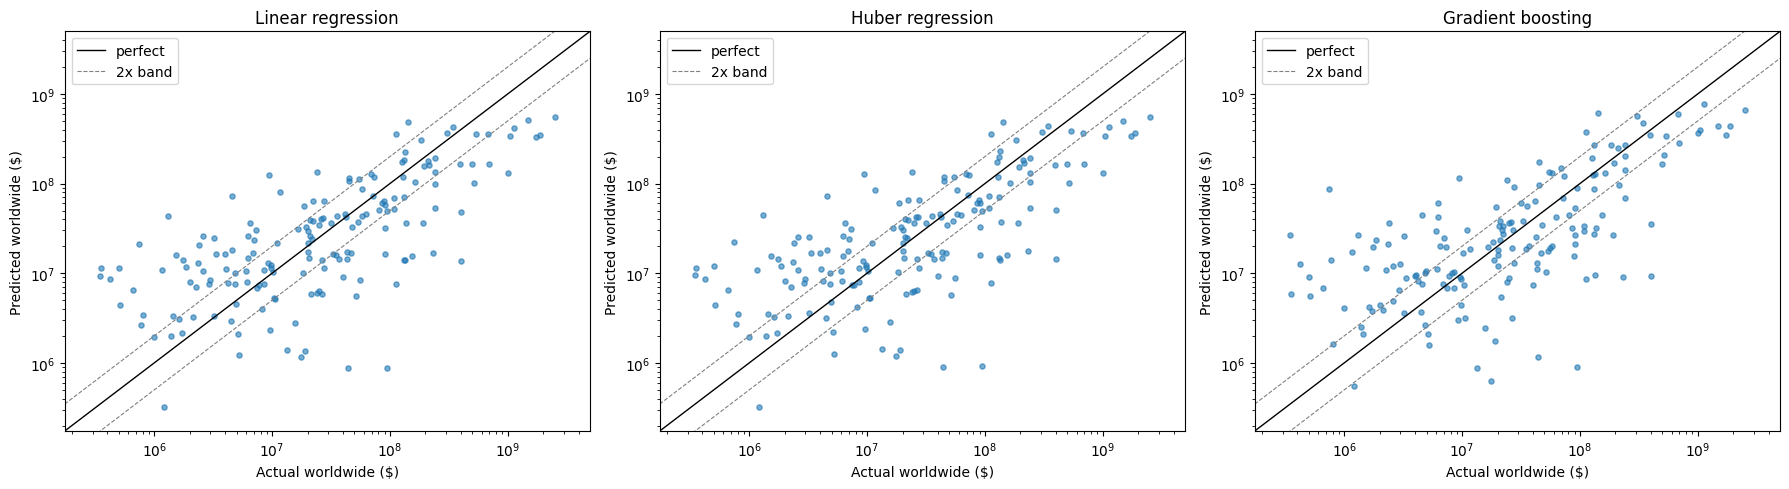

In [203]:
def plot_predicted_vs_actual(y_true_log: pd.Series, predictions: dict, skip=("Median baseline",)):
    names = [n for n in predictions if n not in skip]
    fig, axes = plt.subplots(1, len(names), figsize=(6 * len(names), 5), squeeze=False)
    actual = np.exp(y_true_log)
    lims = [actual.min() * 0.5, actual.max() * 2]
    for ax, name in zip(axes[0], names):
        ax.scatter(actual, np.exp(predictions[name]), s=14, alpha=0.6)
        ax.plot(lims, lims, color="black", lw=1, label="perfect")
        ax.plot(lims, [l * 2 for l in lims], color="grey", lw=0.8, ls="--", label="2x band")
        ax.plot(lims, [l / 2 for l in lims], color="grey", lw=0.8, ls="--")
        ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims,
               xlabel="Actual worldwide ($)", ylabel="Predicted worldwide ($)", title=name)
        ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


plot_predicted_vs_actual(y_test, test_predictions)

## 10. Linear regression: coefficients

scikit-learn doesn't report standard errors, so `ols_coefficient_table` computes them with the classic OLS formula. How to read the table:
- **`log_budget`**: an elasticity. A 1% bigger budget means roughly `coef`% higher gross.
- **0/1 features**: `pct_effect = (exp(coef) - 1) * 100` is the % change in gross versus the baseline category, holding everything else fixed.
- **`p_value`** < 0.05 is the usual "statistically distinguishable from zero" threshold. With correlated features (e.g. Animation & Family), individual p-values can be unstable.

In [204]:
def ols_coefficient_table(model: LinearRegression, X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    X_design = np.column_stack([np.ones(len(X)), X.to_numpy(dtype=float)])
    residuals = y.to_numpy() - model.predict(X)
    dof = X_design.shape[0] - X_design.shape[1]
    sigma2 = residuals @ residuals / dof
    covariance = sigma2 * np.linalg.pinv(X_design.T @ X_design)
    std_err = np.sqrt(np.diag(covariance))

    coef = np.r_[model.intercept_, model.coef_]
    t_stat = coef / std_err
    p_value = 2 * stats.t.sf(np.abs(t_stat), dof)

    return pd.DataFrame(
        {
            "coef": coef,
            "std_err": std_err,
            "p_value": p_value,
            "pct_effect": (np.exp(coef) - 1) * 100,
        },
        index=["intercept"] + list(X.columns),
    )

In [205]:
linear_model = fitted_models["Linear regression"]
coef_table = ols_coefficient_table(linear_model, X_train, y_train)
coef_table.round(3)

,coef,std_err,p_value,pct_effect
intercept,2.644,1.073,0.014,1307.298
log_budget,0.814,0.063,0.000,125.690
starpower_B,-0.128,0.131,0.331,-11.986
starpower_A,0.093,0.150,0.534,9.792
rating_PG-13,-0.208,0.305,0.495,-18.804
rating_R,-0.613,0.305,0.045,-45.833
rating_NR,-0.233,0.335,0.488,-20.750
genre_Drama,-0.184,0.156,0.238,-16.817
genre_Comedy,-0.302,0.136,0.026,-26.057
genre_Action,0.154,0.147,0.296,16.695


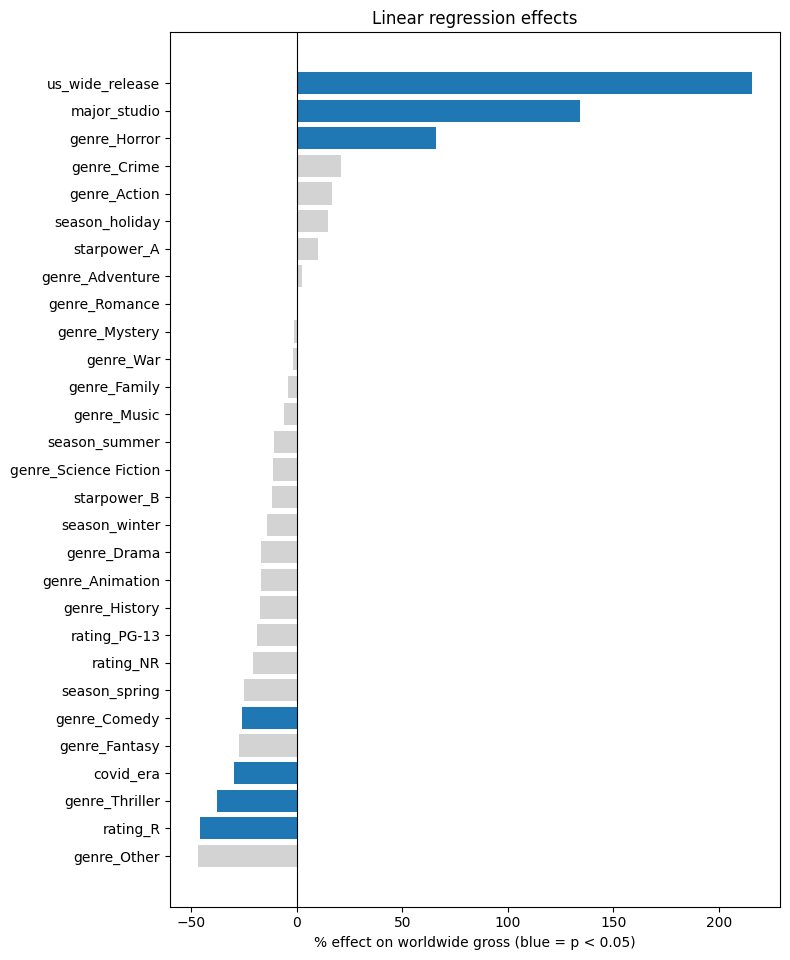

In [206]:
# Visual: % effect of each 0/1 feature (log_budget and intercept excluded, they're on a different scale)
effects = coef_table.drop(index=["intercept", "log_budget"], errors="ignore").sort_values("pct_effect")
colors = ["tab:blue" if p < 0.05 else "lightgrey" for p in effects["p_value"]]

fig, ax = plt.subplots(figsize=(8, 0.3 * len(effects) + 1))
ax.barh(effects.index, effects["pct_effect"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="% effect on worldwide gross (blue = p < 0.05)", title="Linear regression effects")
plt.tight_layout()
plt.show()

## 11. Huber regression: coefficients and down-weighted films

Huber's coefficients side by side with ordinary least squares (OLS). `pct_effect` reads the same way as in section 10. Big differences show where a few extreme films were steering the OLS estimate. Huber has no simple standard-error formula, so there are no p-values here. Use the OLS table for significance.

In [207]:
huber_model = fitted_models["Huber regression"]

coef_comparison = pd.DataFrame(
    {
        "ols_coef": np.r_[linear_model.intercept_, linear_model.coef_],
        "huber_coef": np.r_[huber_model.intercept_, huber_model.coef_],
    },
    index=["intercept"] + list(X_train.columns),
)
coef_comparison["ols_pct_effect"] = (np.exp(coef_comparison["ols_coef"]) - 1) * 100
coef_comparison["huber_pct_effect"] = (np.exp(coef_comparison["huber_coef"]) - 1) * 100
coef_comparison["ols_p_value"] = coef_table["p_value"]
coef_comparison.round(3)

,ols_coef,huber_coef,ols_pct_effect,huber_pct_effect,ols_p_value
intercept,2.644,2.833,1307.298,1600.149,0.014
log_budget,0.814,0.808,125.690,124.272,0.000
starpower_B,-0.128,-0.120,-11.986,-11.309,0.331
starpower_A,0.093,0.116,9.792,12.286,0.534
rating_PG-13,-0.208,-0.268,-18.804,-23.516,0.495
rating_R,-0.613,-0.662,-45.833,-48.398,0.045
rating_NR,-0.233,-0.289,-20.750,-25.088,0.488
genre_Drama,-0.184,-0.210,-16.817,-18.910,0.238
genre_Comedy,-0.302,-0.304,-26.057,-26.191,0.026
genre_Action,0.154,0.155,16.695,16.807,0.296


The training films Huber treated as outliers (`outliers_`): their residual was beyond `HUBER_EPSILON` x the estimated scale, so their pull on the fit was capped. Expect breakout hits at the top and flops at the bottom.

In [208]:
def huber_outlier_table(model: HuberRegressor, films_df: pd.DataFrame, X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    out = films_df.loc[model.outliers_, ["Movie", "Release Date", "Budget", "Worldwide"]].copy()
    out["Predicted"] = np.exp(model.predict(X[model.outliers_]))
    out["Ratio (actual/pred)"] = out["Worldwide"] / out["Predicted"]
    for col in ["Budget", "Worldwide", "Predicted"]:
        out[col] = (out[col] / 1e6).round(1)
    out = out.rename(columns={"Budget": "Budget ($M)", "Worldwide": "Worldwide ($M)", "Predicted": "Predicted ($M)"})
    return out.sort_values("Ratio (actual/pred)", ascending=False)


huber_outliers = huber_outlier_table(huber_model, train_films, X_train, y_train)
print(f"{len(huber_outliers)} of {len(X_train)} training films down-weighted "
      f"(scale = {huber_model.scale_:.2f} on the log scale, threshold = {HUBER_EPSILON * huber_model.scale_:.2f})")
huber_outliers.round(2)

17 of 676 training films down-weighted (scale = 1.21 on the log scale, threshold = 3.04)


,Movie,Release Date,Budget ($M),Worldwide ($M),Predicted ($M),Ratio (actual/pred)
653,Saiyaara,2025-07-18,5.5,63.5,2.6,24.51
520,Savages,2024-10-16,12.3,0.8,17.4,0.05
116,The Requin,2022-01-28,8.5,0.1,3.0,0.04
130,Gold,2022-03-11,6.5,0.2,4.2,0.04
614,Sneaks,2025-04-18,30.0,0.9,21.5,0.04
675,Madharaasi,2025-09-04,24.0,0.7,26.9,0.03
11,Cosmic Sin,2021-03-12,20.0,0.3,13.4,0.03
115,The King's Daughter,2022-01-21,40.5,2.2,88.7,0.02
451,Poolman,2024-05-10,10.0,0.2,7.3,0.02
546,Nightbitch,2024-12-06,20.0,0.2,8.5,0.02


### Epsilon sweep

How the choice of `HUBER_EPSILON` trades off robustness against fit. A smaller ε caps more films. As ε gets large, Huber turns into ordinary least squares. Use the cross-validation columns to pick ε; the test columns are only for a final check. "folds 1–4" leaves out fold 0, whose training window is tiny and noisy.

In [209]:
def huber_epsilon_sweep(epsilons: list[float]) -> pd.DataFrame:
    rows = []
    for eps in epsilons:
        make_model = lambda: HuberRegressor(epsilon=eps, max_iter=HUBER_MAX_ITER)
        cv = cross_validate_model(make_model, X_train, y_train, CV_SPLITS)
        model = make_model().fit(X_train, y_train)
        test = evaluate(y_test, model.predict(X_test))
        rows.append({
            "epsilon": eps,
            "% train down-weighted": model.outliers_.mean() * 100,
            "CV R2": cv["R2 (log)"].mean(),
            "CV R2 (folds 1-4)": cv["R2 (log)"].iloc[1:].mean(),
            "CV within 2x (%)": cv["Within 2x (%)"].mean(),
            "test R2": test["R2 (log)"],
            "test within 2x (%)": test["Within 2x (%)"],
        })
    return pd.DataFrame(rows).set_index("epsilon")


huber_epsilon_sweep([1.35, 1.75, 2.0, 2.5, 3.0, 4.0]).round(3)

,% train down-weighted,CV R2,CV R2 (folds 1-4),CV within 2x (%),test R2,test within 2x (%)
epsilon,,,,,,
1.35,37.130,0.390,0.526,38.929,0.457,40.237
1.75,13.018,0.420,0.535,40.179,0.466,42.012
2.00,7.249,0.414,0.537,40.714,0.468,41.420
2.50,2.515,0.436,0.537,40.536,0.469,44.379
3.00,1.331,0.437,0.535,40.536,0.468,42.012
4.00,0.000,0.437,0.534,40.357,0.468,42.012


## 12. Gradient boosting: permutation importance

This shuffles one feature at a time on the **test** set and measures how much R² drops. A bigger drop means the model leans on that feature more. Unlike linear coefficients, it captures non-linear effects and interactions, but it doesn't tell you the *direction* of the effect.

In [210]:
def permutation_importance_table(model, X: pd.DataFrame, y: pd.Series, n_repeats: int = 20) -> pd.DataFrame:
    result = permutation_importance(model, X, y, n_repeats=n_repeats, random_state=RANDOM_STATE, scoring="r2")
    return (
        pd.DataFrame({"importance_mean": result.importances_mean, "importance_std": result.importances_std},
                     index=X.columns)
        .sort_values("importance_mean", ascending=False)
    )

In [211]:
gbm_importance = permutation_importance_table(fitted_models["Gradient boosting"], X_test, y_test)
gbm_importance.round(4)

,importance_mean,importance_std
log_budget,0.5366,0.0951
major_studio,0.0754,0.0150
genre_Horror,0.0437,0.0134
rating_R,0.0177,0.0145
us_wide_release,0.0108,0.0173
genre_Animation,0.0092,0.0060
genre_Crime,0.0081,0.0073
genre_Adventure,0.0066,0.0052
season_winter,0.0040,0.0029
genre_Comedy,0.0034,0.0098


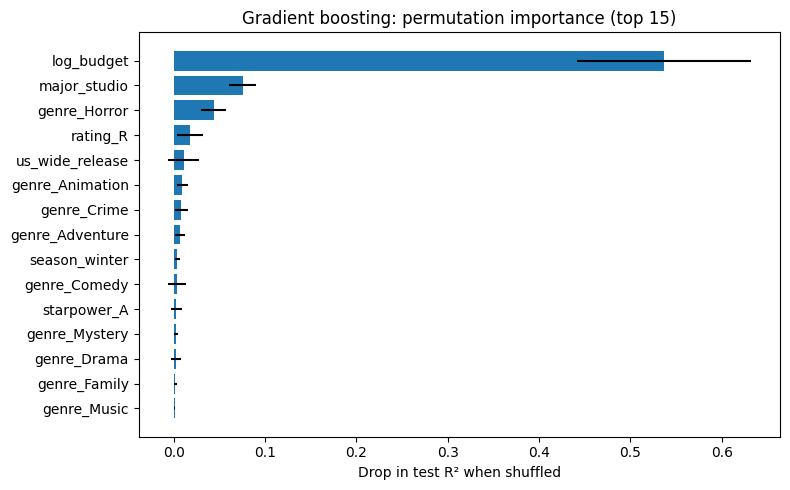

In [212]:
top = gbm_importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top["importance_mean"], xerr=top["importance_std"])
ax.set(xlabel="Drop in test R² when shuffled", title="Gradient boosting: permutation importance (top 15)")
plt.tight_layout()
plt.show()

## 13. Biggest misses

Films where the model was furthest off on the test set. These often point to missing features, such as franchise/sequel status, IP, reviews or marketing spend.

In [213]:
def biggest_misses(films_df: pd.DataFrame, y_pred_log: np.ndarray, n: int = 15) -> pd.DataFrame:
    out = films_df[["Movie", "Release Date", "Budget", "Starpower Rating", "Genres", "Worldwide"]].copy()
    out["Predicted"] = np.exp(y_pred_log)
    out["Ratio (actual/pred)"] = out["Worldwide"] / out["Predicted"]
    out["abs_log_error"] = np.abs(np.log(out["Ratio (actual/pred)"]))
    out = out.sort_values("abs_log_error", ascending=False).head(n)
    for col in ["Budget", "Worldwide", "Predicted"]:
        out[col] = (out[col] / 1e6).round(1)
    return out.rename(columns={"Budget": "Budget ($M)", "Worldwide": "Worldwide ($M)", "Predicted": "Predicted ($M)"})

In [214]:
MODEL_TO_INSPECT = "Huber regression"   # or "Linear regression" / "Gradient boosting"
biggest_misses(test_films, test_predictions[MODEL_TO_INSPECT]).round(2)

,Movie,Release Date,Budget ($M),Starpower Rating,Genres,Worldwide ($M),Predicted ($M),Ratio (actual/pred),abs_log_error
10,Prisoner of War,2025-09-19,2.0,C,"Action, War, Thriller, History",94.7,0.9,103.57,4.64
112,Exit 8,2026-04-10,1.4,C,"Mystery, Thriller, Horror",43.9,0.9,48.28,3.88
12,Afterburn,2025-09-19,60.0,A,"Action, Science Fiction, Comedy",1.3,44.8,0.03,3.52
76,Miss Moxy,2026-01-16,10.0,C,"Adventure, Animation, Comedy, Family",0.4,11.4,0.03,3.48
121,Desert Warrior,2026-04-24,150.0,B,"History, War, Action",0.7,22.1,0.03,3.39
138,Backrooms,2026-05-29,10.0,B,"Horror, Mystery, Science Fiction",400.7,14.3,28.08,3.34
51,Altered,2025-11-21,15.0,C,"Science Fiction, Action",0.3,9.5,0.04,3.32
0,Baaghi 4,2025-09-05,8.7,C,"Action, Romance, Thriller",0.5,11.9,0.04,3.17
60,The Chronology of Water,2025-12-05,7.0,C,Drama,0.4,8.6,0.05,3.02
61,Ella McCay,2025-12-12,35.0,B,"Comedy, Drama",4.5,72.0,0.06,2.76


## 14. Predict a new film: decision report

For each film you describe, the report gives:
- **Predicted worldwide gross:** the model's median outcome. Half of similar films do better, half do worse.
- **Likely range (±1 SD):** where about 2 in 3 similar films land.
- **Chance of breaking even:** the probability that worldwide gross reaches `BREAKEVEN_MULTIPLE` x the production budget (default 2.5x). The 2.5x rule of thumb comes from cinemas keeping roughly half of ticket sales, with marketing often costing another 50–100% of the budget. Set it to whatever matches your costs.

**Budget can be exact or a range:** `"Budget": 60_000_000` or `"Budget": (50_000_000, 75_000_000)`. A range is evaluated at `BUDGET_RANGE_POINTS` budgets, evenly spaced on the log scale. The headline uses the geometric midpoint, and a table shows how the odds change across the range.

Steps in this section:
1. Refit the models on all cleaned films.
2. **Calibrate the uncertainty.** Collect the primary model's out-of-sample misses: validation folds 1–4 from section 8 plus the test set. Measure their spread separately for each segment. Major-studio films are far more predictable than independents, so one global spread would mislead.
3. **Check calibration.** Do films the model gave a 30% break-even chance actually break even about 30% of the time?
4. Describe the films, render the report and plot the odds.

In [215]:
final_common_genres = get_common_genres(films, RARE_GENRE_MIN_COUNT, ALWAYS_KEEP_GENRES)
X_all = build_features(films, final_common_genres)
y_all = build_target(films)

final_models = {
    name: MODEL_FACTORIES[name]().fit(X_all, y_all)
    for name in ["Linear regression", "Huber regression", "Gradient boosting"]
}
print(f"Refit on {len(X_all)} films with {X_all.shape[1]} features")

Refit on 845 films with 30 features


### 14a. Calibrate the uncertainty

The spread of the primary model's out-of-sample misses, per segment. `used_sd` is what the report uses. A factor of 2.7x means a typical miss is the prediction times or divided by 2.7.

In [216]:
def uncertainty_segment(features: pd.DataFrame) -> pd.Series:
    """Segment label per row. Release scale and major-studio backing drive how predictable a film is."""
    wide = np.where(features["us_wide_release"] == 1, "wide", "limited")
    studio = np.where(features["major_studio"] == 1, "major studio", "no major studio")
    return pd.Series([f"{w}, {s}" for w, s in zip(wide, studio)], index=features.index)


def out_of_sample_residuals(model_name: str) -> pd.DataFrame:
    """Log-scale misses on films the model hadn't seen: CV folds 1..k (fold 0's training window is too small) + test set."""
    make_model = MODEL_FACTORIES[model_name]
    parts = []

    def frame(films_df, X, y, log_pred):
        return pd.DataFrame({
            "Movie": films_df["Movie"].to_numpy(),
            "budget": films_df["Budget"].to_numpy(),
            "segment": uncertainty_segment(X).to_numpy(),
            "log_pred": np.asarray(log_pred),
            "log_actual": y.to_numpy(),
        })

    for fold, (train_idx, val_idx) in enumerate(TimeSeriesSplit(n_splits=CV_SPLITS).split(X_train)):
        if fold == 0:
            continue
        model = make_model().fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        parts.append(frame(train_films.iloc[val_idx], X_train.iloc[val_idx], y_train.iloc[val_idx],
                           model.predict(X_train.iloc[val_idx])))
    parts.append(frame(test_films, X_test, y_test, test_predictions[model_name]))

    residuals = pd.concat(parts, ignore_index=True)
    residuals["resid"] = residuals["log_actual"] - residuals["log_pred"]
    return residuals


def segment_spread_table(residuals: pd.DataFrame, min_films: int) -> pd.DataFrame:
    """Per-segment SD of log misses. Small segments fall back to the overall SD."""
    overall_sd = residuals["resid"].std()
    table = residuals.groupby("segment")["resid"].agg(films="count", sd="std")
    table["used_sd"] = np.where(table["films"] >= min_films, table["sd"], overall_sd)
    table["source"] = np.where(table["films"] >= min_films, "segment", f"overall (< {min_films} films)")
    table.loc["(overall)"] = [len(residuals), overall_sd, overall_sd, "overall"]
    table["1 SD = factor of"] = np.exp(table["used_sd"].astype(float))
    return table


oos_residuals = out_of_sample_residuals(PRIMARY_MODEL)
segment_spread = segment_spread_table(oos_residuals, MIN_SEGMENT_FILMS)
print(f"{len(oos_residuals)} out-of-sample predictions from {PRIMARY_MODEL}")
segment_spread.round(2)

617 out-of-sample predictions from Huber regression


,films,sd,used_sd,source,1 SD = factor of
segment,,,,,
"limited, major studio",6,1.69,1.39,overall (< 30 films),4.01
"limited, no major studio",67,1.93,1.93,segment,6.88
"wide, major studio",212,1.01,1.01,segment,2.76
"wide, no major studio",332,1.45,1.45,segment,4.28
(overall),617,1.39,1.39,overall,4.01


### 14b. Calibration check

Group the out-of-sample films by the break-even chance the model would have given them, and compare with how often they actually broke even. Matching columns mean the percentages in the report can be taken at face value.

In [217]:
def probability_at_least(log_estimate, threshold, sd):
    """P(actual >= threshold) when log(actual) ~ Normal(log_estimate, sd)."""
    return 1 - stats.norm.cdf((np.log(threshold) - log_estimate) / sd)


def calibration_table(residuals: pd.DataFrame, spread: pd.DataFrame, multiple: float) -> pd.DataFrame:
    """Predicted break-even chance vs how often those films actually broke even."""
    sd = residuals["segment"].map(spread["used_sd"]).astype(float)
    threshold = multiple * residuals["budget"]
    predicted = probability_at_least(residuals["log_pred"], threshold, sd)
    actual = residuals["log_actual"] >= np.log(threshold)
    table = pd.DataFrame({"predicted": predicted, "actual": actual.astype(int)})
    table["predicted chance"] = pd.cut(table["predicted"], [0, 0.2, 0.4, 0.6, 0.8, 1.0], include_lowest=True)
    return (table.groupby("predicted chance", observed=True)
            .agg(films=("actual", "count"), avg_predicted=("predicted", "mean"), actually_broke_even=("actual", "mean")))


# Same residuals set both the spread and this check, so it's mildly optimistic; it still catches a badly-off model.
calibration_table(oos_residuals, segment_spread, BREAKEVEN_MULTIPLE).round(2)

,films,avg_predicted,actually_broke_even
predicted chance,,,
"(-0.001, 0.2]",133,0.15,0.18
"(0.2, 0.4]",320,0.29,0.30
"(0.4, 0.6]",141,0.48,0.44
"(0.6, 0.8]",20,0.67,0.65
"(0.8, 1.0]",3,0.83,0.67


### 14c. Forecast and report functions

In [ ]:
def required_movie_fields() -> list[str]:
    """Fields build_features reads. Flag fields are only needed when that group is kept in the model."""
    fields = ["Movie", "Release Date", "Budget", "Rating", "Genres", "Starpower Rating",
              "Production Companies", "US Wide Release"]
    if not EXCLUDE_NETFLIX:
        fields.append("Is Netflix")
    if not EXCLUDE_CHINESE:
        fields.append("Is Chinese")
    return fields


def budget_scenarios(budget) -> list[float]:
    """An exact budget -> [budget]. A (low, high) range -> BUDGET_RANGE_POINTS budgets, evenly spaced on the log scale."""
    if isinstance(budget, (tuple, list)):
        low, high = budget
        if not 0 < low <= high:
            raise ValueError(f"Budget range must be (low, high) with 0 < low <= high, got {budget}")
        return list(np.geomspace(low, high, BUDGET_RANGE_POINTS))
    return [float(budget)]


def movie_features(movie: dict) -> pd.DataFrame:
    """One-row feature matrix for a film with an exact budget, aligned to the final training columns."""
    row = pd.DataFrame([movie])
    row["Release Date"] = pd.to_datetime(row["Release Date"])
    return build_features(row, final_common_genres).reindex(columns=X_all.columns, fill_value=0)


def forecast(movie: dict, model_name: str = None) -> dict:
    """Prediction, +-1 SD range and threshold probabilities for one film at one exact budget."""
    model_name = model_name or PRIMARY_MODEL
    features = movie_features(movie)
    log_estimate = float(final_models[model_name].predict(features)[0])
    segment = uncertainty_segment(features).iloc[0]
    sd = float(segment_spread.loc[segment, "used_sd"]) if segment in segment_spread.index else float(segment_spread.loc["(overall)", "used_sd"])
    budget = movie["Budget"]
    return {
        "budget": budget,
        "estimate": np.exp(log_estimate),
        "sd1_low": np.exp(log_estimate - sd),
        "sd1_high": np.exp(log_estimate + sd),
        "sd": sd,
        "segment": segment,
        "segment_films": int(segment_spread.loc[segment, "films"]) if segment in segment_spread.index else 0,
        "p_breakeven": float(probability_at_least(log_estimate, BREAKEVEN_MULTIPLE * budget, sd)),
        "p_multiples": {m: float(probability_at_least(log_estimate, m * budget, sd)) for m in PROBABILITY_MULTIPLES},
    }


KNOWN_COMPANIES = set(MAJOR_STUDIOS) | {c for cs in films["Production Companies"].map(split_companies) for c in cs}


def company_warnings(movie: dict) -> list[str]:
    """Companies the model has never seen (major-studio matching is exact), with close-match suggestions."""
    from difflib import get_close_matches
    warnings = []
    for company in sorted(split_companies(movie["Production Companies"]) - {""}):
        if company in KNOWN_COMPANIES:
            continue
        suggestions = get_close_matches(company, sorted(MAJOR_STUDIOS), n=2, cutoff=0.5) or \
                      get_close_matches(company, sorted(KNOWN_COMPANIES), n=3, cutoff=0.6)
        hint = f" Did you mean {' or '.join(repr(s) for s in suggestions)}?" if suggestions else ""
        warnings.append(f"'{company}' isn't a company the model knows, so it doesn't count toward major_studio.{hint}")
    return warnings


def validate_movies(movies: list[dict]) -> None:
    for movie in movies:
        missing = [f for f in required_movie_fields() if f not in movie]
        if missing:
            raise ValueError(f"{movie.get('Movie', 'A film')} is missing {missing}")

In [ ]:
from IPython.display import Markdown, display

WHAT_IF_MAJOR_STUDIO = "Universal Pictures"   # any name in MAJOR_STUDIOS; used for the "if a major studio releases it" line


def fmt_money(x: float) -> str:
    if x >= 1e9:
        return f"${x / 1e9:.2f}B"
    if x >= 10e6:
        return f"${x / 1e6:,.0f}M"
    return f"${x / 1e6:.1f}M"


def fmt_pct(p: float) -> str:
    return "<1%" if p < 0.01 else (">99%" if p > 0.99 else f"{p:.0%}")


def describe_inputs(movie: dict) -> str:
    budget = movie["Budget"]
    budget_text = (f"{fmt_money(budget[0])} – {fmt_money(budget[1])}" if isinstance(budget, (tuple, list))
                   else fmt_money(budget))
    companies = split_companies(movie["Production Companies"]) - {""}
    majors = sorted(companies & MAJOR_STUDIOS)
    studio = (f"major studio: yes ({', '.join(majors)})" if majors
              else f"major studio: no ({movie['Production Companies'] or 'no companies listed'})")
    release = "wide release" if movie["US Wide Release"] else "limited release"
    return (f"Budget {budget_text} · {movie['Rating']} · {movie['Genres']} · Starpower {movie['Starpower Rating']} · "
            f"{release} · releases {movie['Release Date']} · {studio}")


def film_report_markdown(movie: dict) -> str:
    budgets = budget_scenarios(movie["Budget"])
    mid_budget = budgets[len(budgets) // 2]
    mid = forecast({**movie, "Budget": mid_budget})
    is_range = len(budgets) > 1
    lines = [f"### {movie['Movie']}", f"*{describe_inputs(movie)}*", ""]
    lines += [f"> ⚠️ {w}" for w in company_warnings(movie)] + ([""] if company_warnings(movie) else [])

    # Headline
    at_budget = f" (at the {fmt_money(mid_budget)} midpoint budget)" if is_range else ""
    lines += [
        "| | |",
        "|---|---|",
        f"| **Predicted worldwide gross** | **{fmt_money(mid['estimate'])}**{at_budget} |",
        f"| **Likely range (±1 SD, ~2 in 3 films)** | {fmt_money(mid['sd1_low'])} – {fmt_money(mid['sd1_high'])} |",
        f"| **Chance of breaking even** (≥ {BREAKEVEN_MULTIPLE:g}x budget = {fmt_money(BREAKEVEN_MULTIPLE * mid_budget)}) "
        f"| **{fmt_pct(mid['p_breakeven'])}** |",
        "",
    ]

    # Probability ladder
    lines += ["**Chance of reaching…**", "", "| Worldwide gross | Multiple of budget | Chance |", "|---|---|---|"]
    for m, p in mid["p_multiples"].items():
        tag = " (break-even)" if m == BREAKEVEN_MULTIPLE else ""
        lines.append(f"| {fmt_money(m * mid_budget)} | {m:g}x{tag} | {fmt_pct(p)} |")
    lines.append("")

    # Budget range table
    if is_range:
        lines += ["**Across the budget range**", "",
                  "| Budget | Predicted gross | Likely range (±1 SD) | Break-even gross | Chance of breaking even |",
                  "|---|---|---|---|---|"]
        for b in budgets:
            f = forecast({**movie, "Budget": b})
            lines.append(f"| {fmt_money(b)} | {fmt_money(f['estimate'])} | {fmt_money(f['sd1_low'])} – {fmt_money(f['sd1_high'])} "
                         f"| {fmt_money(BREAKEVEN_MULTIPLE * b)} | {fmt_pct(f['p_breakeven'])} |")
        lines.append("")

    # What-if: major studio
    if movie_features({**movie, "Budget": mid_budget})["major_studio"].iloc[0] == 0:
        alt = forecast({**movie, "Budget": mid_budget,
                        "Production Companies": ", ".join(filter(None, [movie["Production Companies"], WHAT_IF_MAJOR_STUDIO]))})
        lines += [f"**What if a major studio releases it?** Predicted {fmt_money(alt['estimate'])}, likely range "
                  f"{fmt_money(alt['sd1_low'])} – {fmt_money(alt['sd1_high'])}, chance of breaking even "
                  f"**{fmt_pct(alt['p_breakeven'])}**.", ""]

    # Other models
    others = [f"{name} {fmt_money(np.exp(final_models[name].predict(movie_features({**movie, 'Budget': mid_budget}))[0]))}"
              for name in final_models if name != PRIMARY_MODEL]
    lines += [f"**Other models' predictions:** {' · '.join(others)}", ""]

    # Footnote
    lines += [f"<sub>{PRIMARY_MODEL}. Uncertainty segment: *{mid['segment']}*. One SD of past misses for this segment "
              f"is a factor of {np.exp(mid['sd']):.1f}x up or down ({mid['segment_films']} out-of-sample films). "
              f"The predicted gross is a median: half of similar films do better.</sub>", "", "---", ""]
    return "\n".join(lines)


def show_prediction_report(movies: list[dict]) -> None:
    validate_movies(movies)
    display(Markdown("\n".join(film_report_markdown(m) for m in movies)))

### 14d. Your films

In [ ]:
# Budget: an exact number (60_000_000) or a (low, high) range (50_000_000, 75_000_000).
# Add more dicts to the list to compare films side by side.
films_to_predict = [
    {
        "Movie": "Film Assignment One",
        "Release Date": "2028-05-16",
        "Budget": (50_000_000, 75_000_000),
        "Production Companies": "Legendary Pictures",   # comma-separated; any name in MAJOR_STUDIOS sets major_studio = 1
        "Rating": "PG-13",
        "Genres": "Action, Adventure, Science Fiction",
        "Starpower Rating": "B",
        "US Wide Release": 1,
        "Is Netflix": 0,
        "Is Chinese": 0,
    },
]

show_prediction_report(films_to_predict)

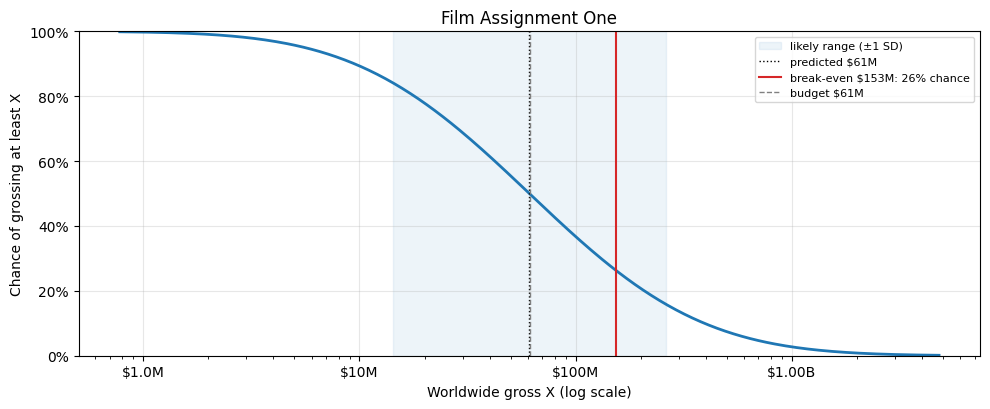

In [223]:
def plot_breakeven_curves(movies: list[dict]) -> None:
    """Chance of reaching at least X worldwide, one panel per film (at the midpoint budget)."""
    fig, axes = plt.subplots(len(movies), 1, figsize=(10, 4.2 * len(movies)), squeeze=False)
    for ax, movie in zip(axes[:, 0], movies):
        budgets = budget_scenarios(movie["Budget"])
        mid_budget = budgets[len(budgets) // 2]
        f = forecast({**movie, "Budget": mid_budget})
        log_est = np.log(f["estimate"])

        grid = np.geomspace(f["estimate"] / np.exp(3 * f["sd"]), f["estimate"] * np.exp(3 * f["sd"]), 300)
        ax.plot(grid, probability_at_least(log_est, grid, f["sd"]), color="tab:blue", lw=2)
        ax.axvspan(f["sd1_low"], f["sd1_high"], color="tab:blue", alpha=0.08, label="likely range (±1 SD)")
        ax.axvline(f["estimate"], color="black", lw=1, ls=":", label=f"predicted {fmt_money(f['estimate'])}")

        breakeven = BREAKEVEN_MULTIPLE * mid_budget
        ax.axvline(breakeven, color="tab:red", lw=1.5,
                   label=f"break-even {fmt_money(breakeven)}: {fmt_pct(f['p_breakeven'])} chance")
        ax.axvline(mid_budget, color="grey", lw=1, ls="--", label=f"budget {fmt_money(mid_budget)}")

        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_money(x)))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        ax.set(ylim=(0, 1), ylabel="Chance of grossing at least X", title=movie["Movie"])
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)
    axes[-1, 0].set_xlabel("Worldwide gross X (log scale)")
    plt.tight_layout()
    plt.show()


plot_breakeven_curves(films_to_predict)

## Ideas for next iterations
- **Sequel / franchise flag**: likely the biggest missing signal (check the "biggest misses" table). TMDB's `belongs_to_collection` field could feed this from `dataset_refiner.ipynb`.
- **Recover films without budgets**: many big anime and international releases (e.g. *Jujutsu Kaisen 0*, *The First Slam Dunk*) are dropped by the refiner's budget filter because TMDB has no budget for them.
- **Interactions for the linear model**, e.g. `log_budget × genre_Animation`, or starpower × budget.
- **Tune `GBM_PARAMS`** with the CV loop in section 8 (try `max_depth`, `learning_rate`, `min_samples_leaf`).
- **Release-month dummies** instead of seasons, or a competition feature (number of wide releases in the same weekend).
- **Ordinal starpower**: flip `STARPOWER_ENCODING` and compare CV scores.